# 第18章: 質的回帰

## 学習目標
- ロジスティック回帰モデルを理解する
- プロビットモデルを理解する
- 最尤推定を適用できる
- オッズ比を解釈できる

## 📋 学習メタ情報

### 推定学習時間
**100〜130分**

### 難易度
**★★★☆☆** (5段階中3)

---

## 🎯 なぜこの章を学ぶのか？

この章の内容は、実務での統計的データ分析に直結する重要なトピックです。理論と実践の両面から理解を深めましょう。

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
import seaborn as sns

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 18.1 ロジスティック回帰

### 問題設定
二値応答変数: $Y \in \{0, 1\}$

### モデル
$$P(Y=1|\mathbf{x}) = \pi(\mathbf{x}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p)}}$$

または
$$\pi(\mathbf{x}) = \frac{e^{\mathbf{x}^T\boldsymbol{\beta}}}{1 + e^{\mathbf{x}^T\boldsymbol{\beta}}}$$

### ロジット変換
$$\log\left(\frac{\pi}{1-\pi}\right) = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p$$

ロジット（対数オッズ）は線形関数

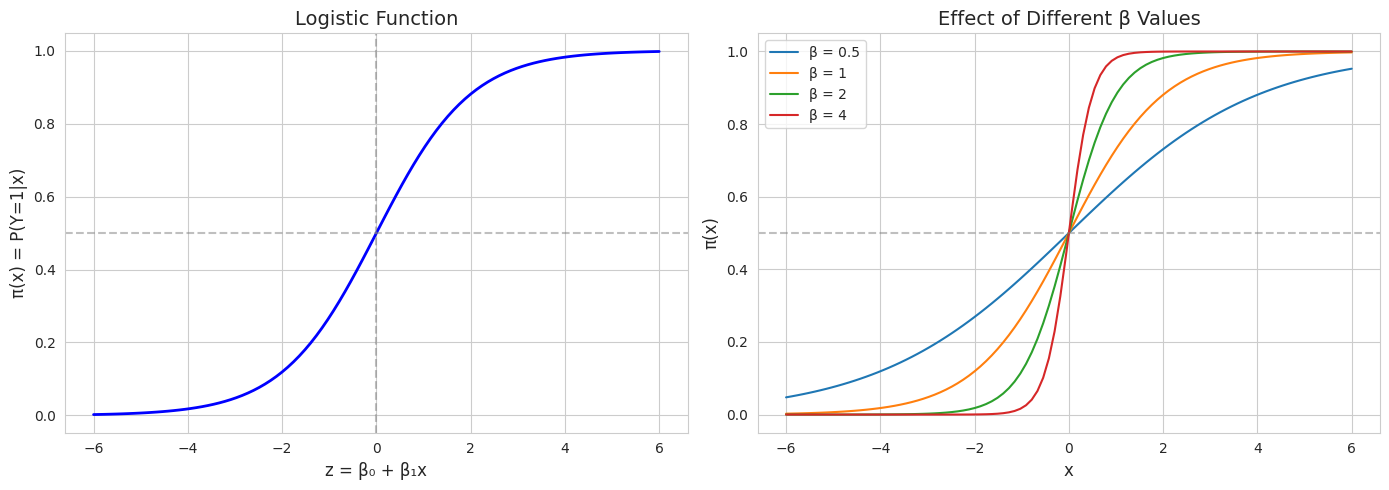

In [2]:
# ロジスティック関数
def sigmoid(z):
    """Logistic (sigmoid) function."""
    return 1 / (1 + np.exp(-z))

# Visualization of logistic function
z = np.linspace(-6, 6, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic function
axes[0].plot(z, sigmoid(z), 'b-', linewidth=2)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('z = β₀ + β₁x', fontsize=12)
axes[0].set_ylabel('π(x) = P(Y=1|x)', fontsize=12)
axes[0].set_title('Logistic Function', fontsize=14)

# Different slopes
for beta in [0.5, 1, 2, 4]:
    axes[1].plot(z, sigmoid(beta * z), label=f'β = {beta}')

axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('π(x)', fontsize=12)
axes[1].set_title('Effect of Different β Values', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

ロジスティック回帰データ

真のパラメータ: β₀ = -1.0, β₁ = 1.5
サンプルサイズ: n = 200
Y=1の数: 77 (38.5%)


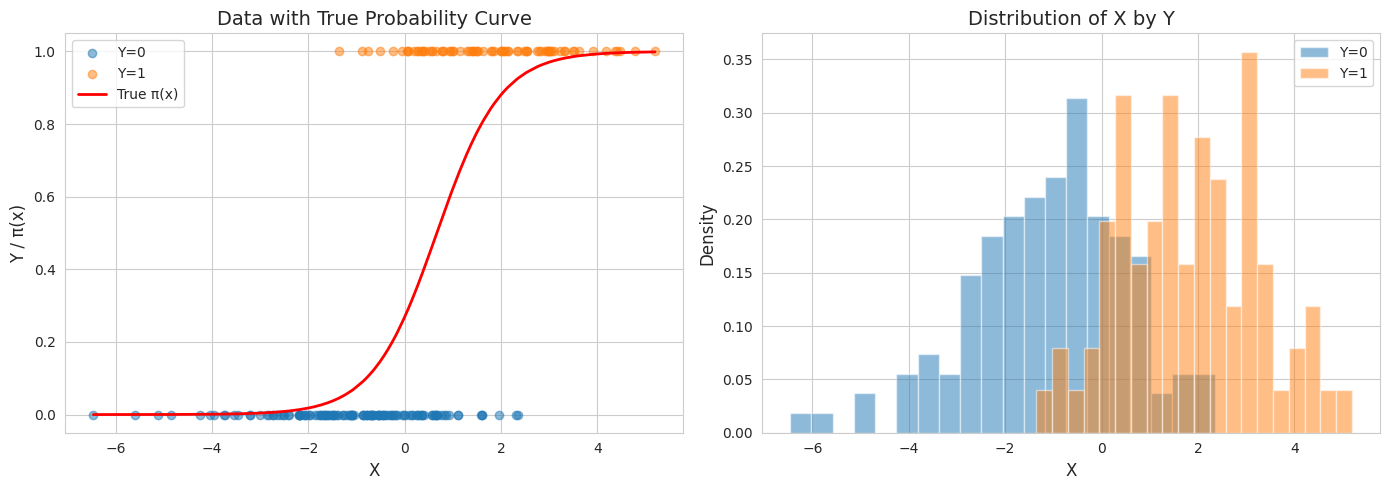

In [3]:
# ロジスティック回帰のデータ生成
np.random.seed(123)

n = 200
X = np.random.normal(0, 2, n)

# True parameters
beta_true = np.array([-1, 1.5])

# Generate binary response
prob = sigmoid(beta_true[0] + beta_true[1] * X)
Y = np.random.binomial(1, prob)

print("ロジスティック回帰データ")
print("="*50)
print(f"\n真のパラメータ: β₀ = {beta_true[0]}, β₁ = {beta_true[1]}")
print(f"サンプルサイズ: n = {n}")
print(f"Y=1の数: {np.sum(Y)} ({np.mean(Y)*100:.1f}%)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Data with true probability
X_sorted = np.sort(X)
prob_sorted = sigmoid(beta_true[0] + beta_true[1] * X_sorted)

axes[0].scatter(X[Y==0], Y[Y==0], alpha=0.5, label='Y=0')
axes[0].scatter(X[Y==1], Y[Y==1], alpha=0.5, label='Y=1')
axes[0].plot(X_sorted, prob_sorted, 'r-', linewidth=2, label='True π(x)')
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('Y / π(x)', fontsize=12)
axes[0].set_title('Data with True Probability Curve', fontsize=14)
axes[0].legend()

# Distribution of X by Y
axes[1].hist(X[Y==0], bins=20, alpha=0.5, label='Y=0', density=True)
axes[1].hist(X[Y==1], bins=20, alpha=0.5, label='Y=1', density=True)
axes[1].set_xlabel('X', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Distribution of X by Y', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 18.2 最尤推定

### 尤度関数
$$L(\boldsymbol{\beta}) = \prod_{i=1}^{n} \pi_i^{y_i}(1-\pi_i)^{1-y_i}$$

### 対数尤度
$$\ell(\boldsymbol{\beta}) = \sum_{i=1}^{n} \left[y_i \log \pi_i + (1-y_i)\log(1-\pi_i)\right]$$

### スコア関数
$$\frac{\partial \ell}{\partial \beta_j} = \sum_{i=1}^{n} (y_i - \pi_i) x_{ij}$$

### ニュートン・ラフソン法（IRLS）
反復的に重み付き最小二乗を適用

In [4]:
# 最尤推定の実装
def logistic_likelihood(beta, X, y):
    """Negative log-likelihood for logistic regression."""
    z = beta[0] + beta[1] * X
    # Use numerically stable computation
    log_lik = np.sum(y * z - np.log(1 + np.exp(z)))
    return -log_lik  # Return negative for minimization

def logistic_gradient(beta, X, y):
    """Gradient of negative log-likelihood."""
    pi = sigmoid(beta[0] + beta[1] * X)
    grad_0 = -np.sum(y - pi)
    grad_1 = -np.sum((y - pi) * X)
    return np.array([grad_0, grad_1])

# Fit using scipy.optimize
initial_beta = np.array([0, 0])
result = minimize(logistic_likelihood, initial_beta, args=(X, Y),
                  method='BFGS', jac=logistic_gradient)

beta_hat = result.x

print("最尤推定結果")
print("="*50)
print(f"\n推定値: β₀ = {beta_hat[0]:.4f}, β₁ = {beta_hat[1]:.4f}")
print(f"真の値: β₀ = {beta_true[0]:.4f}, β₁ = {beta_true[1]:.4f}")
print(f"\n対数尤度: {-result.fun:.4f}")
print(f"収束: {result.success}")

# Standard errors using Hessian
def logistic_hessian(beta, X, y):
    """Hessian of negative log-likelihood."""
    pi = sigmoid(beta[0] + beta[1] * X)
    W = pi * (1 - pi)
    
    H = np.zeros((2, 2))
    H[0, 0] = np.sum(W)
    H[0, 1] = H[1, 0] = np.sum(W * X)
    H[1, 1] = np.sum(W * X**2)
    
    return H

H = logistic_hessian(beta_hat, X, Y)
cov_matrix = np.linalg.inv(H)
se = np.sqrt(np.diag(cov_matrix))

# z-statistics and p-values
z_stats = beta_hat / se
p_values = 2 * (1 - stats.norm.cdf(np.abs(z_stats)))

print(f"\n{'変数':<10} {'推定値':>10} {'標準誤差':>10} {'z値':>10} {'p値':>10}")
print("-"*55)
for i, name in enumerate(['Intercept', 'X']):
    print(f"{name:<10} {beta_hat[i]:>10.4f} {se[i]:>10.4f} "
          f"{z_stats[i]:>10.4f} {p_values[i]:>10.4f}")

最尤推定結果

推定値: β₀ = -0.9987, β₁ = 1.4287
真の値: β₀ = -1.0000, β₁ = 1.5000

対数尤度: -68.6811
収束: True

変数                推定値       標準誤差         z値         p値
-------------------------------------------------------
Intercept     -0.9987     0.2361    -4.2295     0.0000
X              1.4287     0.2057     6.9469     0.0000


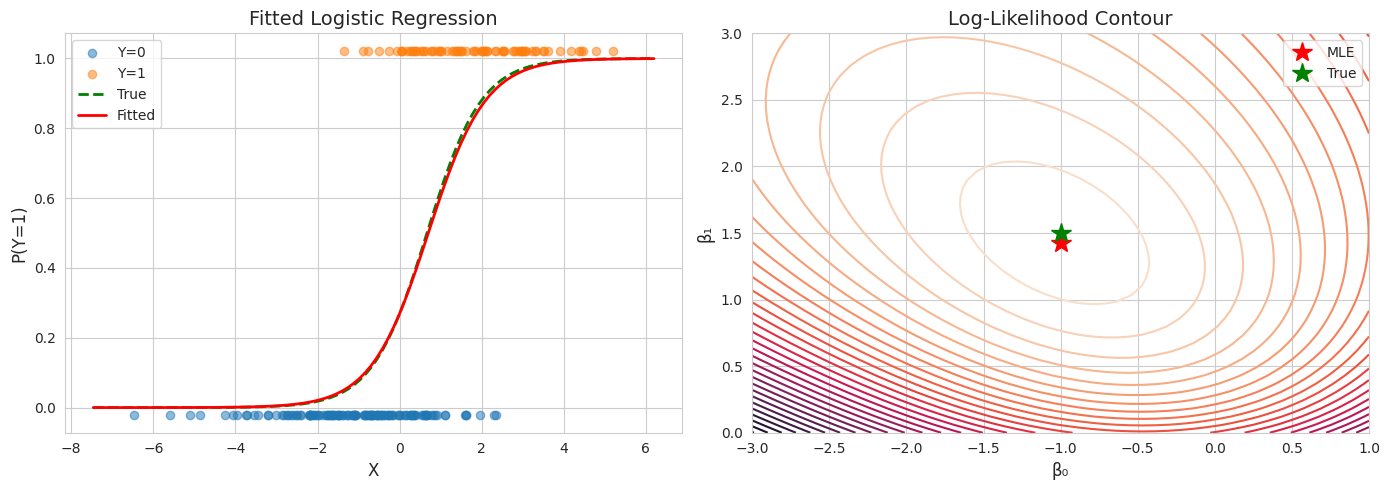

In [5]:
# フィット結果の可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fitted curve
X_plot = np.linspace(X.min()-1, X.max()+1, 100)
prob_true = sigmoid(beta_true[0] + beta_true[1] * X_plot)
prob_fit = sigmoid(beta_hat[0] + beta_hat[1] * X_plot)

axes[0].scatter(X[Y==0], Y[Y==0] - 0.02, alpha=0.5, label='Y=0')
axes[0].scatter(X[Y==1], Y[Y==1] + 0.02, alpha=0.5, label='Y=1')
axes[0].plot(X_plot, prob_true, 'g--', linewidth=2, label='True')
axes[0].plot(X_plot, prob_fit, 'r-', linewidth=2, label='Fitted')
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('P(Y=1)', fontsize=12)
axes[0].set_title('Fitted Logistic Regression', fontsize=14)
axes[0].legend()

# Log-likelihood surface
beta0_range = np.linspace(-3, 1, 50)
beta1_range = np.linspace(0, 3, 50)
B0, B1 = np.meshgrid(beta0_range, beta1_range)
LL = np.zeros_like(B0)

for i in range(len(beta0_range)):
    for j in range(len(beta1_range)):
        LL[j, i] = -logistic_likelihood([B0[j, i], B1[j, i]], X, Y)

axes[1].contour(B0, B1, LL, levels=30)
axes[1].plot(beta_hat[0], beta_hat[1], 'r*', markersize=15, label='MLE')
axes[1].plot(beta_true[0], beta_true[1], 'g*', markersize=15, label='True')
axes[1].set_xlabel('β₀', fontsize=12)
axes[1].set_ylabel('β₁', fontsize=12)
axes[1].set_title('Log-Likelihood Contour', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 18.3 オッズ比の解釈

### オッズ
$$\text{odds} = \frac{\pi}{1-\pi}$$

### オッズ比
$x$ が1単位増加したときのオッズ比:
$$OR = \frac{\text{odds}(x+1)}{\text{odds}(x)} = e^{\beta}$$

### 解釈
- $\beta > 0$: オッズが増加（$OR > 1$）
- $\beta = 0$: オッズは変わらない（$OR = 1$）
- $\beta < 0$: オッズが減少（$OR < 1$）

オッズ比の解釈

β₁ = 1.4287
オッズ比 = exp(β₁) = 4.1731
95%信頼区間: [2.7887, 6.2448]

解釈: Xが1単位増加すると、Y=1のオッズは4.17倍になる

具体例:
     X     P(Y=1)       Odds
------------------------------
    -2     0.0207     0.0212
     0     0.2692     0.3684
     2     0.8651     6.4152


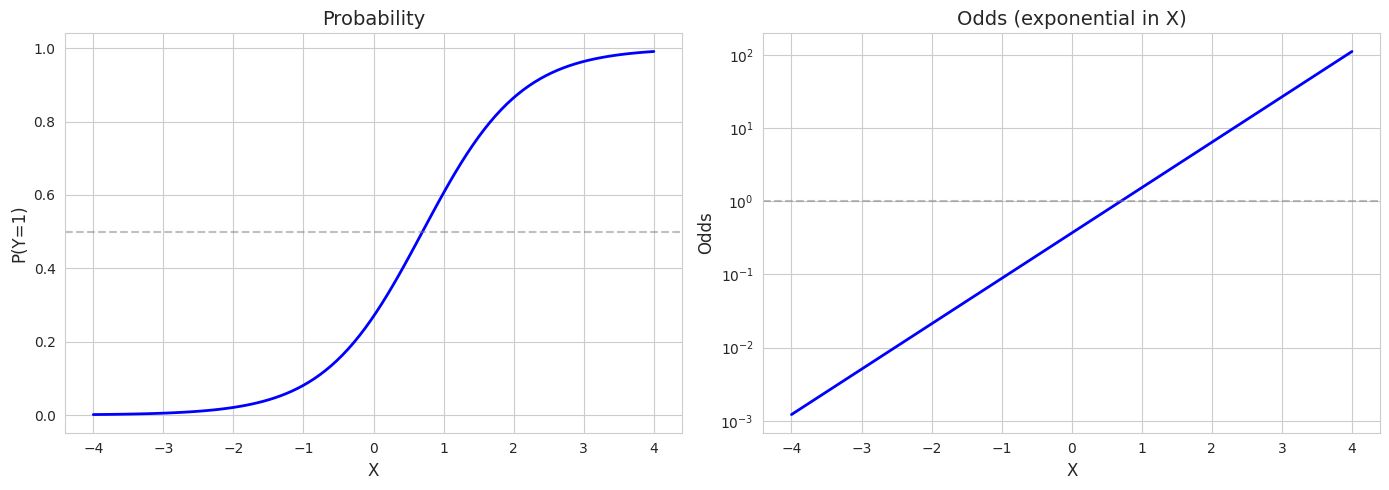

In [6]:
# オッズ比の計算と解釈
OR = np.exp(beta_hat[1])
OR_lower = np.exp(beta_hat[1] - 1.96 * se[1])
OR_upper = np.exp(beta_hat[1] + 1.96 * se[1])

print("オッズ比の解釈")
print("="*50)
print(f"\nβ₁ = {beta_hat[1]:.4f}")
print(f"オッズ比 = exp(β₁) = {OR:.4f}")
print(f"95%信頼区間: [{OR_lower:.4f}, {OR_upper:.4f}]")
print(f"\n解釈: Xが1単位増加すると、Y=1のオッズは{OR:.2f}倍になる")

# Example calculation
x_values = [-2, 0, 2]
print(f"\n具体例:")
print(f"{'X':>6} {'P(Y=1)':>10} {'Odds':>10}")
print("-"*30)
for x in x_values:
    p = sigmoid(beta_hat[0] + beta_hat[1] * x)
    odds = p / (1 - p)
    print(f"{x:>6} {p:>10.4f} {odds:>10.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Probability vs X
X_plot = np.linspace(-4, 4, 100)
prob_plot = sigmoid(beta_hat[0] + beta_hat[1] * X_plot)

axes[0].plot(X_plot, prob_plot, 'b-', linewidth=2)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('X', fontsize=12)
axes[0].set_ylabel('P(Y=1)', fontsize=12)
axes[0].set_title('Probability', fontsize=14)

# Odds vs X
odds_plot = prob_plot / (1 - prob_plot)
axes[1].plot(X_plot, odds_plot, 'b-', linewidth=2)
axes[1].axhline(1, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('X', fontsize=12)
axes[1].set_ylabel('Odds', fontsize=12)
axes[1].set_title('Odds (exponential in X)', fontsize=14)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## 18.4 プロビットモデル

### モデル
$$P(Y=1|\mathbf{x}) = \Phi(\beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p)$$

ここで $\Phi$ は標準正規分布の累積分布関数

### ロジットとプロビットの比較
- ロジスティック分布は正規分布より裾が重い
- プロビットの $\beta$ をロジットに変換: $\beta_{logit} \approx 1.6 \cdot \beta_{probit}$

ロジットとプロビットの比較

モデル                  β₀         β₁
----------------------------------------
Logit           -0.9987     1.4287
Probit          -0.5813     0.8215
Probit×1.6      -0.9301     1.3144


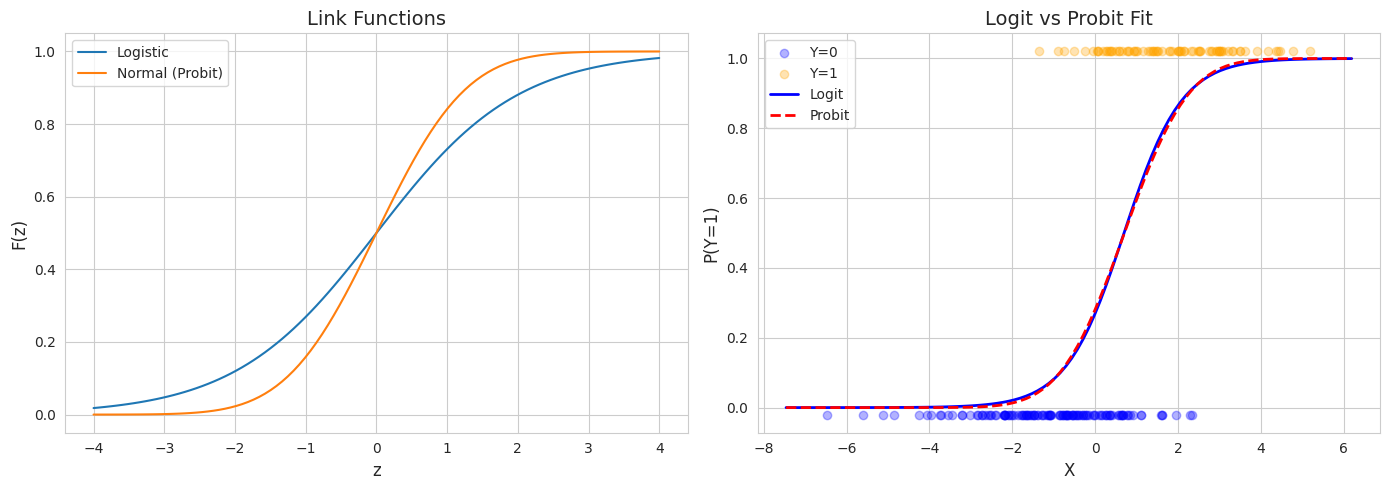

In [7]:
# プロビットモデルの実装
def probit_likelihood(beta, X, y):
    """Negative log-likelihood for probit regression."""
    z = beta[0] + beta[1] * X
    pi = stats.norm.cdf(z)
    
    # Avoid log(0)
    pi = np.clip(pi, 1e-10, 1-1e-10)
    
    log_lik = np.sum(y * np.log(pi) + (1 - y) * np.log(1 - pi))
    return -log_lik

# Fit probit model
result_probit = minimize(probit_likelihood, initial_beta, args=(X, Y),
                         method='BFGS')
beta_probit = result_probit.x

print("ロジットとプロビットの比較")
print("="*50)
print(f"\n{'モデル':<12} {'β₀':>10} {'β₁':>10}")
print("-"*40)
print(f"{'Logit':<12} {beta_hat[0]:>10.4f} {beta_hat[1]:>10.4f}")
print(f"{'Probit':<12} {beta_probit[0]:>10.4f} {beta_probit[1]:>10.4f}")
print(f"{'Probit×1.6':<12} {beta_probit[0]*1.6:>10.4f} {beta_probit[1]*1.6:>10.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Link functions
z = np.linspace(-4, 4, 100)
logit_cdf = sigmoid(z)
probit_cdf = stats.norm.cdf(z)

axes[0].plot(z, logit_cdf, label='Logistic')
axes[0].plot(z, probit_cdf, label='Normal (Probit)')
axes[0].set_xlabel('z', fontsize=12)
axes[0].set_ylabel('F(z)', fontsize=12)
axes[0].set_title('Link Functions', fontsize=14)
axes[0].legend()

# Fitted curves comparison
X_plot = np.linspace(X.min()-1, X.max()+1, 100)
prob_logit = sigmoid(beta_hat[0] + beta_hat[1] * X_plot)
prob_probit = stats.norm.cdf(beta_probit[0] + beta_probit[1] * X_plot)

axes[1].scatter(X[Y==0], Y[Y==0] - 0.02, alpha=0.3, label='Y=0', color='blue')
axes[1].scatter(X[Y==1], Y[Y==1] + 0.02, alpha=0.3, label='Y=1', color='orange')
axes[1].plot(X_plot, prob_logit, 'b-', linewidth=2, label='Logit')
axes[1].plot(X_plot, prob_probit, 'r--', linewidth=2, label='Probit')
axes[1].set_xlabel('X', fontsize=12)
axes[1].set_ylabel('P(Y=1)', fontsize=12)
axes[1].set_title('Logit vs Probit Fit', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 18.5 モデル評価

### 尤度比検定
$$G^2 = 2(\ell_{full} - \ell_{null}) \sim \chi^2(p)$$

### 疑似決定係数
$$R^2_{McFadden} = 1 - \frac{\ell_{full}}{\ell_{null}}$$

### 混同行列と正確度

In [8]:
# モデル評価
# Null model (intercept only)
p_null = np.mean(Y)
log_lik_null = np.sum(Y * np.log(p_null) + (1 - Y) * np.log(1 - p_null))

# Full model
log_lik_full = -logistic_likelihood(beta_hat, X, Y)

# Likelihood ratio test
G2 = 2 * (log_lik_full - log_lik_null)
p_value_lr = 1 - stats.chi2.cdf(G2, 1)

# Pseudo R-squared
R2_mcfadden = 1 - log_lik_full / log_lik_null

print("モデル評価")
print("="*50)
print(f"\n対数尤度 (Null): {log_lik_null:.4f}")
print(f"対数尤度 (Full): {log_lik_full:.4f}")
print(f"\n尤度比検定: G² = {G2:.4f}, p = {p_value_lr:.6f}")
print(f"McFadden R² = {R2_mcfadden:.4f}")

# Confusion matrix
Y_pred = (sigmoid(beta_hat[0] + beta_hat[1] * X) > 0.5).astype(int)

TP = np.sum((Y == 1) & (Y_pred == 1))
TN = np.sum((Y == 0) & (Y_pred == 0))
FP = np.sum((Y == 0) & (Y_pred == 1))
FN = np.sum((Y == 1) & (Y_pred == 0))

accuracy = (TP + TN) / n
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print(f"\n混同行列:")
print(f"           Predicted")
print(f"           0    1")
print(f"Actual 0  {TN:>3}  {FP:>3}")
print(f"       1  {FN:>3}  {TP:>3}")

print(f"\n正確度: {accuracy:.4f}")
print(f"感度 (Recall): {sensitivity:.4f}")
print(f"特異度: {specificity:.4f}")

モデル評価

対数尤度 (Null): -133.2918
対数尤度 (Full): -68.6811

尤度比検定: G² = 129.2213, p = 0.000000
McFadden R² = 0.4847

混同行列:
           Predicted
           0    1
Actual 0  111   12
       1   20   57

正確度: 0.8400
感度 (Recall): 0.7403
特異度: 0.9024


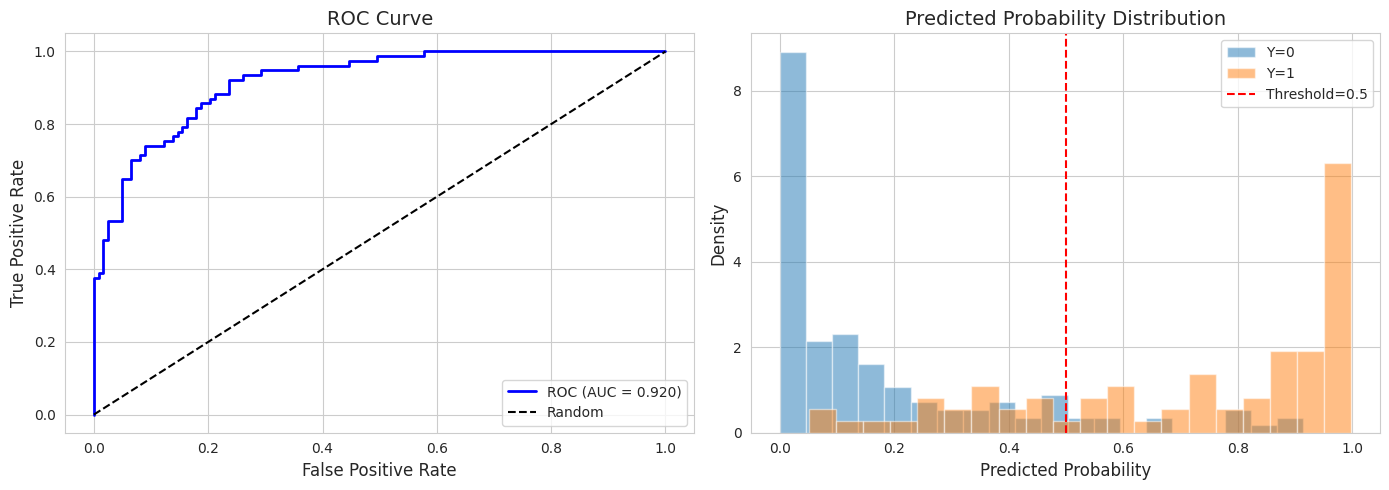

In [9]:
# ROC曲線
from sklearn.metrics import roc_curve, auc

prob_pred = sigmoid(beta_hat[0] + beta_hat[1] * X)
fpr, tpr, thresholds = roc_curve(Y, prob_pred)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curve
axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curve', fontsize=14)
axes[0].legend()

# Predicted probability distribution
axes[1].hist(prob_pred[Y==0], bins=20, alpha=0.5, label='Y=0', density=True)
axes[1].hist(prob_pred[Y==1], bins=20, alpha=0.5, label='Y=1', density=True)
axes[1].axvline(0.5, color='red', linestyle='--', label='Threshold=0.5')
axes[1].set_xlabel('Predicted Probability', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Predicted Probability Distribution', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## 18.6 練習問題

### 問題1
以下のデータでロジスティック回帰を行い、係数を推定せよ。

X = [1, 2, 3, 4, 5, 6, 7, 8]
Y = [0, 0, 0, 1, 0, 1, 1, 1]

### 問題2
ロジスティック回帰で β₁ = 0.5 のとき:
(a) オッズ比を計算せよ
(b) xが2単位増加したときのオッズ比を求めよ

### 問題3
ロジスティック回帰とプロビット回帰の違いを説明せよ。

問題1: ロジスティック回帰

推定係数:
  β₀ = -5.7703
  β₁ = 1.2823

モデル: logit(π) = -5.7703 + 1.2823*X


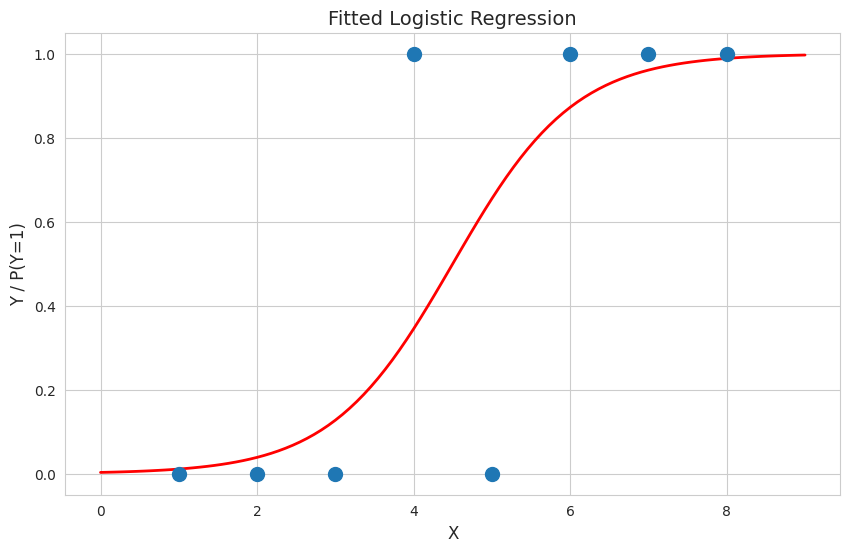

In [10]:
# 問題1の解答
print("問題1: ロジスティック回帰")
print("="*50)

X_prob = np.array([1, 2, 3, 4, 5, 6, 7, 8])
Y_prob = np.array([0, 0, 0, 1, 0, 1, 1, 1])

# Fit logistic regression
result_prob = minimize(logistic_likelihood, [0, 0], args=(X_prob, Y_prob),
                       method='BFGS', jac=logistic_gradient)
beta_prob = result_prob.x

print(f"\n推定係数:")
print(f"  β₀ = {beta_prob[0]:.4f}")
print(f"  β₁ = {beta_prob[1]:.4f}")
print(f"\nモデル: logit(π) = {beta_prob[0]:.4f} + {beta_prob[1]:.4f}*X")

# Visualization
X_plot = np.linspace(0, 9, 100)
prob_plot = sigmoid(beta_prob[0] + beta_prob[1] * X_plot)

plt.figure(figsize=(10, 6))
plt.scatter(X_prob, Y_prob, s=100, zorder=5)
plt.plot(X_plot, prob_plot, 'r-', linewidth=2)
plt.xlabel('X', fontsize=12)
plt.ylabel('Y / P(Y=1)', fontsize=12)
plt.title('Fitted Logistic Regression', fontsize=14)
plt.show()

In [11]:
# 問題2の解答
print("問題2: オッズ比の計算")
print("="*50)

beta1 = 0.5

# (a) OR for 1 unit increase
OR_1 = np.exp(beta1)
print(f"\n(a) β₁ = {beta1} のとき")
print(f"    オッズ比 = exp({beta1}) = {OR_1:.4f}")
print(f"    → xが1単位増加するとオッズは{OR_1:.2f}倍")

# (b) OR for 2 unit increase
OR_2 = np.exp(2 * beta1)
print(f"\n(b) xが2単位増加したとき")
print(f"    オッズ比 = exp(2 × {beta1}) = {OR_2:.4f}")
print(f"    または {OR_1:.4f}² = {OR_1**2:.4f}")

問題2: オッズ比の計算

(a) β₁ = 0.5 のとき
    オッズ比 = exp(0.5) = 1.6487
    → xが1単位増加するとオッズは1.65倍

(b) xが2単位増加したとき
    オッズ比 = exp(2 × 0.5) = 2.7183
    または 1.6487² = 2.7183


In [12]:
# 問題3の解答
print("問題3: ロジスティック回帰とプロビット回帰の比較")
print("="*50)

print("""
【ロジスティック回帰】
- リンク関数: ロジスティック（シグモイド）関数
- P(Y=1) = 1 / (1 + exp(-z))
- 係数の解釈: オッズ比として直接解釈可能
- 裾が重い分布（外れ値に対して頑健）

【プロビット回帰】
- リンク関数: 標準正規分布の累積分布関数
- P(Y=1) = Φ(z)
- 係数の解釈: 限界効果で解釈
- 裾が軽い分布
- 潜在変数モデルとの関連が自然

【実用上の違い】
- 結果はほぼ同じ（βprobit ≈ βlogit / 1.6）
- ロジスティック回帰のほうが一般的
- オッズ比の解釈が必要な場合はロジスティック
- 計量経済学ではプロビットも多用
""")

問題3: ロジスティック回帰とプロビット回帰の比較

【ロジスティック回帰】
- リンク関数: ロジスティック（シグモイド）関数
- P(Y=1) = 1 / (1 + exp(-z))
- 係数の解釈: オッズ比として直接解釈可能
- 裾が重い分布（外れ値に対して頑健）

【プロビット回帰】
- リンク関数: 標準正規分布の累積分布関数
- P(Y=1) = Φ(z)
- 係数の解釈: 限界効果で解釈
- 裾が軽い分布
- 潜在変数モデルとの関連が自然

【実用上の違い】
- 結果はほぼ同じ（βprobit ≈ βlogit / 1.6）
- ロジスティック回帰のほうが一般的
- オッズ比の解釈が必要な場合はロジスティック
- 計量経済学ではプロビットも多用



## ⚠️ よくある間違いと解決策

統計分析では、手法の前提条件を確認せずに適用してしまうことがよくあります。必ず前提を確認し、適切な手法を選択しましょう。

---

## 📝 理解度チェック

この章で学んだ内容を振り返り、重要な概念を自分の言葉で説明できるか確認しましょう。

---

## 📚 まとめ

お疲れ様でした！この章で学んだ手法は、実際のデータ分析で頻繁に使われます。実データで試して理解を深めましょう。

---